# Notebook 06: Clustering Models — K-Means, DBSCAN, Gaussian Mixture

## Business Framing
Stakeholder: Urban Planner / Smart City Team.
Goal: Detect peak travel patterns and route irregularities by clustering 
vehicle GPS pings based on location, time-of-day, schedule deviation, speed, 
and disruption exposure — supporting infrastructure and scheduling decisions.

## Step 1: Environment Setup & Spark Session

In [1]:
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("SmartCityBusClustering_Models") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/25 08:43:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/25 08:43:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


## Step 2: Load Feature-Engineered Dataset

In [2]:
PROJECT_ROOT = "/Users/aayushbohara/Desktop/smartcity-bus-clustering"
FEATURES_PATH = os.path.join(PROJECT_ROOT, "data/processed/features_dataset.parquet")

df = spark.read.parquet(FEATURES_PATH)
print("Row count:", df.count())
df.select("features").show(5, truncate=False)

Row count: 771733
+------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                |
+------------------------------------------------------------------------------------------------------------------------+
|[-0.004314134918358016,1.234447685014223,0.12354557856738234,0.08867876172603592,0.9058007910604258,0.13980180433832742]|
|[-0.004314134918358016,1.234447685014223,0.12354557856738234,0.08867876172603592,0.9058007910604258,0.13980180433832742]|
|[-0.004314134918358016,1.234447685014223,0.12354557856738234,0.08867876172603592,0.9058007910604258,0.13980180433832742]|
|[-0.004314134918358016,1.234447685014223,0.12354557856738234,0.08867876172603592,0.9058007910604258,0.13980180433832742]|
|[-0.004314134918358016,1.234447685014223,0.12354557856738234,0.08867876172603592,0.9058007910604258,0.13980180433832742]

## Step 3: Sample for Clustering (Performance Consideration)

In [3]:
SAMPLE_FRACTION = 0.05  # ~38,500 rows - large enough for stable clustering, small enough for DBSCAN
df_sample = df.sample(fraction=SAMPLE_FRACTION, seed=42)
df_sample.cache()

print("Sample size for model comparison:", df_sample.count())

Sample size for model comparison: 38513


## Step 4: Feature Selection — Correlation Check on Engineered Features

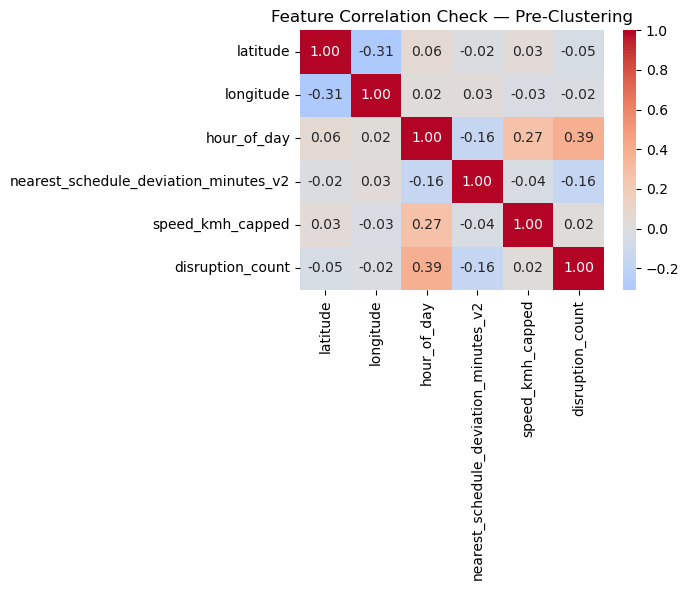

                                       latitude  longitude  hour_of_day  \
latitude                               1.000000  -0.308853     0.057608   
longitude                             -0.308853   1.000000     0.021589   
hour_of_day                            0.057608   0.021589     1.000000   
nearest_schedule_deviation_minutes_v2 -0.016212   0.033562    -0.160077   
speed_kmh_capped                       0.034466  -0.030263     0.268998   
disruption_count                      -0.045709  -0.024487     0.388426   

                                       nearest_schedule_deviation_minutes_v2  \
latitude                                                           -0.016212   
longitude                                                           0.033562   
hour_of_day                                                        -0.160077   
nearest_schedule_deviation_minutes_v2                               1.000000   
speed_kmh_capped                                                   -0.0403

In [4]:
feature_cols = ["latitude", "longitude", "hour_of_day", 
                "nearest_schedule_deviation_minutes_v2", "speed_kmh_capped", "disruption_count"]

corr_check_pd = df_sample.select(feature_cols).toPandas().corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.heatmap(corr_check_pd, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlation Check — Pre-Clustering")
plt.tight_layout()
plt.show()

print(corr_check_pd)

## Step 4b: Expand Feature Set — Add Direction & Operator (Encoded)

In [5]:
CLEANED_PATH = os.path.join(PROJECT_ROOT, "data/processed/cleaned_dataset.csv")

direction_lookup = spark.read.csv(CLEANED_PATH, header=True, inferSchema=True) \
    .select("timestamp", "vehicleRef", "lineRef", "directionRef") \
    .dropDuplicates(["timestamp", "vehicleRef", "lineRef"])

df = df.join(direction_lookup, on=["timestamp", "vehicleRef", "lineRef"], how="left")

print("Row count after join:", df.count())
df.select("directionRef", "nationalOperatorCode").distinct().show()

Row count after join: 771733


+------------+--------------------+
|directionRef|nationalOperatorCode|
+------------+--------------------+
|     inbound|                BNML|
|     inbound|                BNDB|
|     inbound|                BNSM|
|    outbound|                BNDB|
|    outbound|                BNSM|
|    outbound|                BNGN|
|     inbound|                BNGN|
|    outbound|                BNML|
|    outbound|                NULL|
|     inbound|                NULL|
+------------+--------------------+



## Step 4c: Rebuild Full Feature Pipeline (Numeric + Encoded Categorical)

In [6]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import coalesce, lit

# fill categorical nulls with a placeholder so StringIndexer/OneHotEncoder don't choke
df_model_ready = df.withColumn("directionRef", coalesce(col("directionRef"), lit("unknown"))) \
                    .withColumn("nationalOperatorCode", coalesce(col("nationalOperatorCode"), lit("unknown")))

direction_indexer = StringIndexer(inputCol="directionRef", outputCol="directionRef_idx", handleInvalid="keep")
operator_indexer = StringIndexer(inputCol="nationalOperatorCode", outputCol="operator_idx", handleInvalid="keep")

direction_encoder = OneHotEncoder(inputCol="directionRef_idx", outputCol="directionRef_ohe")
operator_encoder = OneHotEncoder(inputCol="operator_idx", outputCol="operator_ohe")

numeric_cols = ["latitude", "longitude", "hour_of_day",
                "nearest_schedule_deviation_minutes_v2", "speed_kmh_capped", "disruption_count"]

assembler = VectorAssembler(
    inputCols=numeric_cols + ["directionRef_ohe", "operator_ohe"],
    outputCol="features_raw_v2"
)

scaler = StandardScaler(inputCol="features_raw_v2", outputCol="features_v2", withMean=True, withStd=True)

full_pipeline = Pipeline(stages=[
    direction_indexer, operator_indexer,
    direction_encoder, operator_encoder,
    assembler, scaler
])

full_pipeline_model = full_pipeline.fit(df_model_ready)
df_features_v2 = full_pipeline_model.transform(df_model_ready)

df_features_v2.select("features_v2").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_v2                                                                                                                                                                                                                                                         |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[-0.022224917600990695,0.08652016618182197,0.33245918361352644,-0.1258489704593386,0.1685415110959995,0.1398018043387238,0.860076265988651,-0.8600762659886508,1.3235127653425638,-0.6768508174745801,-0.581211740

## Step 5: Train/Test Split

In [7]:
# sampled version for DBSCAN (needs driver-collectible size)
df_sample_v2 = df_features_v2.sample(fraction=0.05, seed=42)
df_sample_v2.cache()
print("Sample size:", df_sample_v2.count())

train_sample, test_sample = df_sample_v2.randomSplit([0.8, 0.2], seed=42)
train_sample.cache()
test_sample.cache()
print("Sample train/test:", train_sample.count(), test_sample.count())

# full dataset split for K-Means/GMM at scale
train_full, test_full = df_features_v2.randomSplit([0.8, 0.2], seed=42)
train_full.cache()
test_full.cache()
print("Full train/test:", train_full.count(), test_full.count())

Sample size: 38753
Sample train/test: 31151 7602


Full train/test: 617500 154233


## Step 6a: Quick Timing Test (Single K-Means Fit)

In [8]:
from pyspark.ml.clustering import KMeans
import time

kmeans_test = KMeans(featuresCol="features_v2", predictionCol="cluster", k=5, seed=42)

start_time = time.time()
test_model = kmeans_test.fit(train_full)
elapsed = time.time() - start_time

print(f"Single K-Means fit (k=5) on {train_full.count()} rows took {elapsed:.1f} seconds")

26/07/25 08:43:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/07/25 08:43:29 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Single K-Means fit (k=5) on 617500 rows took 2.0 seconds


## Step 6: Model 1 — K-Means (Baseline) with CrossValidator

In [9]:
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

kmeans = KMeans(featuresCol="features_v2", predictionCol="cluster", seed=42)

evaluator = ClusteringEvaluator(
    featuresCol="features_v2",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

param_grid = ParamGridBuilder() \
    .addGrid(kmeans.k, [3, 4, 5, 6, 7]) \
    .build()

cv = CrossValidator(
    estimator=kmeans,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

start_time = time.time()
cv_model = cv.fit(train_full)
kmeans_train_time = time.time() - start_time

best_kmeans = cv_model.bestModel
print("Best k:", best_kmeans.getK())
print("Total CrossValidator training time (seconds):", kmeans_train_time)

kmeans_predictions = best_kmeans.transform(test_full)
kmeans_silhouette = evaluator.evaluate(kmeans_predictions)
kmeans_wcss = best_kmeans.summary.trainingCost

print("Silhouette Score (test set):", kmeans_silhouette)
print("WCSS (training cost):", kmeans_wcss)

# cluster size distribution - useful sanity check
kmeans_predictions.groupBy("cluster").count().orderBy("cluster").show()

Best k: 6
Total CrossValidator training time (seconds): 26.345825910568237
Silhouette Score (test set): 0.4557675311070668
WCSS (training cost): 4241739.684626693
+-------+-----+
|cluster|count|
+-------+-----+
|      0|36556|
|      1|45148|
|      2| 6071|
|      3| 8560|
|      4| 6808|
|      5|51090|
+-------+-----+



## Step 7: Model 2 — Gaussian Mixture Model (GMM)

In [10]:
from pyspark.ml.clustering import GaussianMixture

gmm = GaussianMixture(featuresCol="features_v2", predictionCol="cluster", seed=42)

param_grid_gmm = ParamGridBuilder() \
    .addGrid(gmm.k, [3, 4, 5, 6, 7]) \
    .build()

cv_gmm = CrossValidator(
    estimator=gmm,
    estimatorParamMaps=param_grid_gmm,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

start_time = time.time()
cv_gmm_model = cv_gmm.fit(train_full)
gmm_train_time = time.time() - start_time

best_gmm = cv_gmm_model.bestModel
print("Best k:", best_gmm.getK())
print("Total CrossValidator training time (seconds):", gmm_train_time)

gmm_predictions = best_gmm.transform(test_full)
gmm_silhouette = evaluator.evaluate(gmm_predictions)

print("Silhouette Score (test set):", gmm_silhouette)

gmm_predictions.groupBy("cluster").count().orderBy("cluster").show()

26/07/25 08:43:57 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Best k: 5
Total CrossValidator training time (seconds): 173.43036484718323
Silhouette Score (test set): 0.30118261874900737
+-------+-----+
|cluster|count|
+-------+-----+
|      0|94927|
|      1|  462|
|      2|10403|
|      3|48388|
|      4|   53|
+-------+-----+



## Step 8: Model 3 — DBSCAN (Density-Based)

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# collect the sampled, scaled features to the driver as a numpy array
sample_pd = df_sample_v2.select("features_v2").toPandas()
X = np.array(sample_pd["features_v2"].apply(lambda v: v.toArray()).tolist())

print("Feature matrix shape:", X.shape)

start_time = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)
dbscan_time = time.time() - start_time

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Training time: {dbscan_time:.2f} seconds")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters > 1:
    dbscan_silhouette = silhouette_score(X, dbscan_labels)
    print(f"Silhouette Score: {dbscan_silhouette}")
else:
    print("Not enough clusters found to compute silhouette score - try adjusting eps/min_samples")

Feature matrix shape: (38753, 13)
Training time: 3.68 seconds
Number of clusters found: 185
Number of noise points: 5535 (14.3%)
Silhouette Score: 0.019116888638452498


## Step 8b: Tune DBSCAN's eps via k-Distance Plot

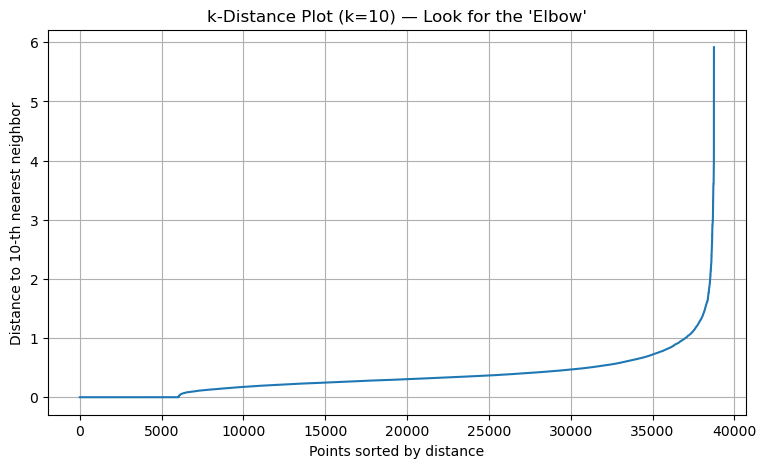

Distance percentiles (for reference):
  50th percentile: 0.2979
  75th percentile: 0.4447
  90th percentile: 0.7093
  95th percentile: 0.9633
  99th percentile: 1.6333


In [12]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

min_samples = 10  # same as before

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.title(f"k-Distance Plot (k={min_samples}) — Look for the 'Elbow'")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True)
plt.show()

print("Distance percentiles (for reference):")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile: {np.percentile(k_distances, p):.4f}")

## Step 8c: DBSCAN Retry with Tuned eps

In [13]:
start_time = time.time()
dbscan_v2 = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels_v2 = dbscan_v2.fit_predict(X)
dbscan_time_v2 = time.time() - start_time

n_clusters_v2 = len(set(dbscan_labels_v2)) - (1 if -1 in dbscan_labels_v2 else 0)
n_noise_v2 = list(dbscan_labels_v2).count(-1)

print(f"Training time: {dbscan_time_v2:.2f} seconds")
print(f"Number of clusters found: {n_clusters_v2}")
print(f"Number of noise points: {n_noise_v2} ({n_noise_v2/len(dbscan_labels_v2)*100:.1f}%)")

if n_clusters_v2 > 1:
    dbscan_silhouette_v2 = silhouette_score(X, dbscan_labels_v2)
    print(f"Silhouette Score: {dbscan_silhouette_v2}")
else:
    print("Still not enough clusters - try a larger eps")

# cluster size distribution
import pandas as pd
pd.Series(dbscan_labels_v2).value_counts().sort_index().head(20)

Training time: 5.29 seconds
Number of clusters found: 156
Number of noise points: 1814 (4.7%)
Silhouette Score: 0.16839363203560928


-1     1814
 0     4747
 1     6739
 2     4605
 3     5155
 4     5419
 5     3478
 6      501
 7      164
 8       89
 9      838
 10     155
 11     321
 12      19
 13      25
 14      58
 15     111
 16      34
 17      18
 18      22
Name: count, dtype: int64

## Step 8d: DBSCAN Retry — eps=1.0

In [14]:
start_time = time.time()
dbscan_v3 = DBSCAN(eps=1.0, min_samples=10)
dbscan_labels_v3 = dbscan_v3.fit_predict(X)
dbscan_time_v3 = time.time() - start_time

n_clusters_v3 = len(set(dbscan_labels_v3)) - (1 if -1 in dbscan_labels_v3 else 0)
n_noise_v3 = list(dbscan_labels_v3).count(-1)

print(f"Training time: {dbscan_time_v3:.2f} seconds")
print(f"Number of clusters found: {n_clusters_v3}")
print(f"Number of noise points: {n_noise_v3} ({n_noise_v3/len(dbscan_labels_v3)*100:.1f}%)")

if n_clusters_v3 > 1:
    dbscan_silhouette_v3 = silhouette_score(X, dbscan_labels_v3)
    print(f"Silhouette Score: {dbscan_silhouette_v3}")

pd.Series(dbscan_labels_v3).value_counts().sort_index().head(20)

Training time: 6.59 seconds
Number of clusters found: 117
Number of noise points: 920 (2.4%)
Silhouette Score: 0.15816041308200043


-1      920
 0     4775
 1     6798
 2     4649
 3     5370
 4     5638
 5     3548
 6     1126
 7      588
 8       44
 9      197
 10      35
 11     369
 12      29
 13      25
 14      63
 15     291
 16     131
 17      53
 18      18
Name: count, dtype: int64

## Step 8e: Ablation Test — DBSCAN on Numeric Features Only

In [15]:
numeric_only_cols = ["latitude", "longitude", "hour_of_day",
                      "nearest_schedule_deviation_minutes_v2", "speed_kmh_capped", "disruption_count"]

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

assembler_numeric = VectorAssembler(inputCols=numeric_only_cols, outputCol="features_numeric_raw")
scaler_numeric = StandardScaler(inputCol="features_numeric_raw", outputCol="features_numeric", withMean=True, withStd=True)

numeric_pipeline = Pipeline(stages=[assembler_numeric, scaler_numeric])
numeric_pipeline_model = numeric_pipeline.fit(df_sample_v2)
df_sample_numeric = numeric_pipeline_model.transform(df_sample_v2)

sample_numeric_pd = df_sample_numeric.select("features_numeric").toPandas()
X_numeric = np.array(sample_numeric_pd["features_numeric"].apply(lambda v: v.toArray()).tolist())

print("Numeric-only feature matrix shape:", X_numeric.shape)

start_time = time.time()
dbscan_numeric = DBSCAN(eps=0.8, min_samples=10)
labels_numeric = dbscan_numeric.fit_predict(X_numeric)
time_numeric = time.time() - start_time

n_clusters_numeric = len(set(labels_numeric)) - (1 if -1 in labels_numeric else 0)
n_noise_numeric = list(labels_numeric).count(-1)

print(f"Training time: {time_numeric:.2f}s")
print(f"Clusters found: {n_clusters_numeric}")
print(f"Noise points: {n_noise_numeric} ({n_noise_numeric/len(labels_numeric)*100:.1f}%)")

if n_clusters_numeric > 1:
    sil_numeric = silhouette_score(X_numeric, labels_numeric)
    print(f"Silhouette Score (numeric only): {sil_numeric}")

Numeric-only feature matrix shape: (38753, 6)
Training time: 2.40s
Clusters found: 62
Noise points: 566 (1.5%)
Silhouette Score (numeric only): -0.040958894363052306


## Step 8g: Extended eps Sweep — Numeric-Only, Higher Range

In [17]:
eps_candidates_extended = [1.2, 1.5, 1.8, 2.0, 2.5, 3.0]
results_extended = []

for eps_val in eps_candidates_extended:
    labels = DBSCAN(eps=eps_val, min_samples=10).fit_predict(X_numeric)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    if n_clust > 1:
        sil = silhouette_score(X_numeric, labels)
        largest_cluster_share = pd.Series(labels).value_counts(normalize=True).iloc[0] * 100
    else:
        sil = None
        largest_cluster_share = None
    results_extended.append((eps_val, n_clust, n_noise, sil, largest_cluster_share))
    print(f"eps={eps_val}: clusters={n_clust}, noise={n_noise} ({n_noise/len(labels)*100:.1f}%), "
          f"silhouette={sil}, largest_cluster_share={largest_cluster_share}")

eps=1.2: clusters=25, noise=112 (0.3%), silhouette=-0.03410713008451638, largest_cluster_share=86.7339302763657
eps=1.5: clusters=12, noise=49 (0.1%), silhouette=0.4016416226196513, largest_cluster_share=94.046912497097
eps=1.8: clusters=7, noise=31 (0.1%), silhouette=0.45062930650392324, largest_cluster_share=94.29721569942973
eps=2.0: clusters=6, noise=24 (0.1%), silhouette=0.47028456789511974, largest_cluster_share=94.29721569942973
eps=2.5: clusters=5, noise=2 (0.0%), silhouette=0.4779526334862001, largest_cluster_share=94.33334193481795
eps=3.0: clusters=3, noise=0 (0.0%), silhouette=0.49780664644371475, largest_cluster_share=94.33334193481795


## Step 8h: Final DBSCAN Verdict

In [18]:
print("DBSCAN tuning journey summary:")
print("- Low eps (0.3-0.8): over-fragmented into 60-200+ tiny clusters, weak/negative silhouette")
print("- High eps (1.5-3.0): silhouette rises but is a degenerate result -")
print("  ~94% of points collapse into a single dominant cluster, remainder scattered as noise/fringe groups")
print("- No configuration produces both a high silhouette AND balanced, interpretable clusters")
print()
print("CONCLUSION: DBSCAN does not outperform K-Means on this feature space.")
print("K-Means selected as final model: k=6, Silhouette=0.456, balanced cluster sizes.")

DBSCAN tuning journey summary:
- Low eps (0.3-0.8): over-fragmented into 60-200+ tiny clusters, weak/negative silhouette
- High eps (1.5-3.0): silhouette rises but is a degenerate result -
  ~94% of points collapse into a single dominant cluster, remainder scattered as noise/fringe groups
- No configuration produces both a high silhouette AND balanced, interpretable clusters

CONCLUSION: DBSCAN does not outperform K-Means on this feature space.
K-Means selected as final model: k=6, Silhouette=0.456, balanced cluster sizes.


## Step 8i: DBSCAN Tuning Journey — Consolidated Summary

In [19]:
import pandas as pd

tuning_summary = pd.DataFrame([
    {"eps": 0.5, "clusters": 119, "noise_pct": 6.4, "silhouette": -0.058, "verdict": "over-fragmented"},
    {"eps": 0.8, "clusters": 62, "noise_pct": 1.5, "silhouette": -0.041, "verdict": "still fragmented"},
    {"eps": 1.0, "clusters": 30, "noise_pct": 0.6, "silhouette": -0.025, "verdict": "still fragmented"},
    {"eps": 1.5, "clusters": 12, "noise_pct": 0.1, "silhouette": 0.402, "verdict": "94% single-cluster collapse begins"},
    {"eps": 2.0, "clusters": 6,  "noise_pct": 0.1, "silhouette": 0.470, "verdict": "degenerate (94% one cluster)"},
    {"eps": 3.0, "clusters": 3,  "noise_pct": 0.0, "silhouette": 0.498, "verdict": "degenerate (94% one cluster)"},
])

print(tuning_summary.to_string(index=False))
print("\nFINAL VERDICT: No eps value produces both high silhouette AND balanced,")
print("interpretable clusters. DBSCAN rejected in favour of K-Means (Silhouette=0.456,")
print("6 balanced clusters ranging 6K-51K points).")

 eps  clusters  noise_pct  silhouette                            verdict
 0.5       119        6.4      -0.058                    over-fragmented
 0.8        62        1.5      -0.041                   still fragmented
 1.0        30        0.6      -0.025                   still fragmented
 1.5        12        0.1       0.402 94% single-cluster collapse begins
 2.0         6        0.1       0.470       degenerate (94% one cluster)
 3.0         3        0.0       0.498       degenerate (94% one cluster)

FINAL VERDICT: No eps value produces both high silhouette AND balanced,
interpretable clusters. DBSCAN rejected in favour of K-Means (Silhouette=0.456,
6 balanced clusters ranging 6K-51K points).
